<a href="https://colab.research.google.com/github/glonsze/Sales-Analytics/blob/main/Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Mate_homework/Final_project/

/content/drive/MyDrive/Mate_homework/Final_project


In [4]:
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")

In [5]:
countries.head() #data on countries

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [6]:
events.head() # data on orders

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [7]:
products.head() # data on products

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


#products/events мають спільні колонки id продукта(products - внутрішній ключ, events має зовнішній ключ) countries/events  мають спільні колонки alpha-3/Country code

In [8]:
events.isna().sum() / events.shape[0] * 100 # precentage of missing values

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


In [9]:
events["Country Code"]= events['Country Code'].fillna("unknown") # The proportion of misisng values ​​is significant; we will replace it with "Unknown".
events["Units Sold"]= events["Units Sold"].fillna(events["Units Sold"].median()) #  Fill in the missing values with the average value

In [10]:
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [11]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1330 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [12]:
events["Order Date"] = pd.to_datetime(events["Order Date"]) # Change “order date” and “ship date” to the “datetime” data type
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [13]:
events.columns = events.columns.str.lower().str.replace(" ", "_") # Instead of a space, we'll use an underscore. This is the style recommended for naming variables and functions in Python.



In [14]:
events['sales_channel'] = events['sales_channel'].str.lower()


In [15]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [16]:
products.isna().sum() / products.shape[1] # There are no missing values

,0
id,0.0
item_type,0.0


In [17]:
# There are no duplicate
print(products.duplicated().sum())
print(events.duplicated().sum())
print(countries.duplicated().sum())

0
0
0


In [18]:
#anomalies
print(events[events["order_date"] > events["ship_date"]].count()) # Was the delivery made before the order was placed?
print(events[events["units_sold"] < 0].count()) # sales were less than 0
 # Unknown categories
events[~events['product_id'].isin(products['id'])]

# There are no anomalies

order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64
order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


In [19]:
events_products = pd.merge(events, products, left_on="product_id", right_on="id") # Join the two tables by product ID
events_products.head()


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal
2,101025998,2014-07-18,2014-08-11,M,unknown,7940,online,4693.0,668.27,502.54,7940,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages


In [20]:
store = pd.merge(events_products, countries, left_on="country_code", right_on="alpha-3") # Join the two tables by country code
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


In [21]:
store = store.drop(columns=["alpha-2", "sub-region", "region"]) # Let's remove the extra columns we won't be working with


In [22]:
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-3
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK


In [23]:
store = store.rename(columns={'name': 'country'}) # Changing the names of the country columns

In [24]:
orders = store["order_id"].count() # number of orders
orders

np.int64(1248)

In [25]:
store["profit"] = (store['unit_price'] - store['unit_cost']) * store["units_sold"] # profit/income
store["profit"] = store["profit"].round(2)
print(f"profit: {store['profit'].sum().round(2)}");
store["cost"] = store['unit_cost'] * store['units_sold'] # expenses/cost
print(f"cost: {store['cost'].sum()}")
store["revenue"] = store["units_sold"] * store["unit_price"] # revenue from sales
print(f"revenue: {store['revenue'].sum()}")

profit: 474117209.18
cost: 1127365514.52
revenue: 1601482723.7


In [26]:
sum(store["revenue"] - store["cost"]) == sum(store["profit"]) # Checking whether the values match

True

In [27]:
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country,alpha-3,profit,cost,revenue
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR,57583.50,76121.50,133705.00
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB,176559.87,233400.23,409960.10
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE,85998.24,41968.64,127966.88
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB,119767.68,243129.92,362897.60
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK,280275.00,1165411.20,1445686.20


In [28]:
unique_countries = store["country"].nunique() # number of countries covered
unique_countries

45

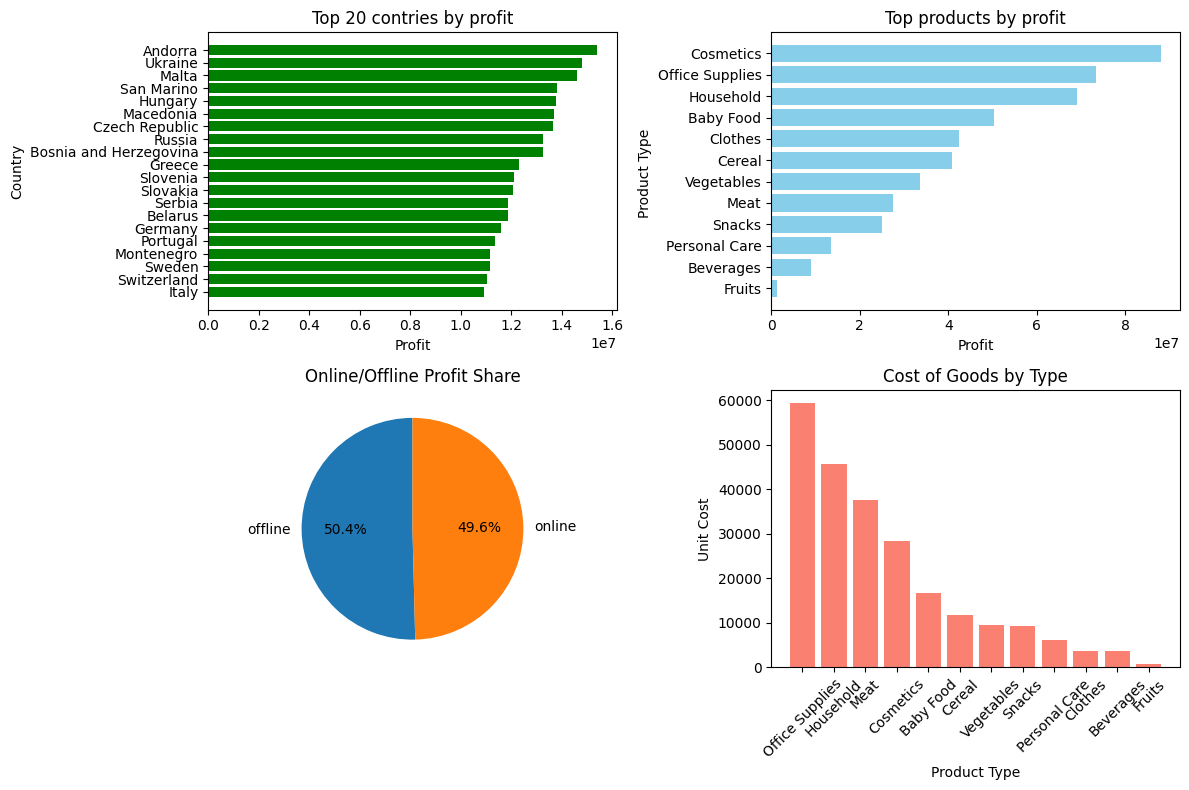

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# countries by profit

country_profits = store.groupby("country")["profit"].sum().sort_values(ascending=False).head(20)

ax[0, 0].barh(country_profits.index, country_profits.values, color="green")
ax[0, 0].set_title("Top 20 contries by profit")
ax[0, 0].set_xlabel("Profit")
ax[0, 0].set_ylabel("Country")
ax[0, 0].invert_yaxis()

# Product Popularity
products_profits = store.groupby("item_type")["profit"].sum().sort_values(ascending=False)

ax[0, 1].barh(products_profits.index, products_profits.values, color="skyblue")
ax[0, 1].set_title("Top products by profit")
ax[0, 1].set_xlabel("Profit")
ax[0, 1].set_ylabel("Product Type ")
ax[0, 1].invert_yaxis()

# Orders by Sales Channel
offline_online_profits = store.groupby("sales_channel")["profit"].sum().sort_values(ascending=False)
ax[1, 0].pie(offline_online_profits.values, labels=offline_online_profits.index, autopct='%1.1f%%', startangle=90)
ax[1, 0].set_title("Online/Offline Profit Share")

# cost of goods
products_costs = store.groupby("item_type")["unit_cost"].sum().sort_values(ascending=False)

ax[1, 1].bar(products_costs.index, products_costs.values, color="salmon")
ax[1, 1].set_title("Cost of Goods by Type")
ax[1, 1].set_xlabel("Product Type")
ax[1, 1].set_ylabel("Unit Cost")

ax[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

In [30]:
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country,alpha-3,profit,cost,revenue
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR,57583.50,76121.50,133705.00
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB,176559.87,233400.23,409960.10
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE,85998.24,41968.64,127966.88
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB,119767.68,243129.92,362897.60
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK,280275.00,1165411.20,1445686.20


In [31]:
store["days"] = store["order_date"].dt.day_name() # Finding the days of the week based on the date

In [32]:
store

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country,alpha-3,profit,cost,revenue,days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR,57583.50,76121.50,133705.00,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB,176559.87,233400.23,409960.10,Thursday
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE,85998.24,41968.64,127966.88,Saturday
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB,119767.68,243129.92,362897.60,Saturday
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK,280275.00,1165411.20,1445686.20,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,994504153,2017-01-10,2017-01-13,M,SWE,4594,online,4734.0,9.33,6.92,4594,Fruits,Sweden,SWE,11408.94,32759.28,44168.22,Tuesday
1244,994978797,2014-12-05,2015-01-02,H,ITA,1270,offline,5192.0,47.45,31.79,1270,Beverages,Italy,ITA,81306.72,165053.68,246360.40,Friday
1245,996754205,2010-09-20,2010-09-22,L,RUS,7331,offline,574.0,255.28,159.42,7331,Baby Food,Russia,RUS,55023.64,91507.08,146530.72,Monday
1246,998043382,2010-06-15,2010-07-03,H,MLT,8293,online,2070.0,437.20,263.33,8293,Cosmetics,Malta,MLT,359910.90,545093.10,905004.00,Tuesday


In [33]:
store['ship_time'] = (store['ship_date'] - store['order_date']).dt.days # Tracking the time from order to delivery

In [34]:
# Check for Negative Values
print(f"Від'ємних значень ship_time: {(store['ship_time'] < 0).sum()}")

Від'ємних значень ship_time: 0


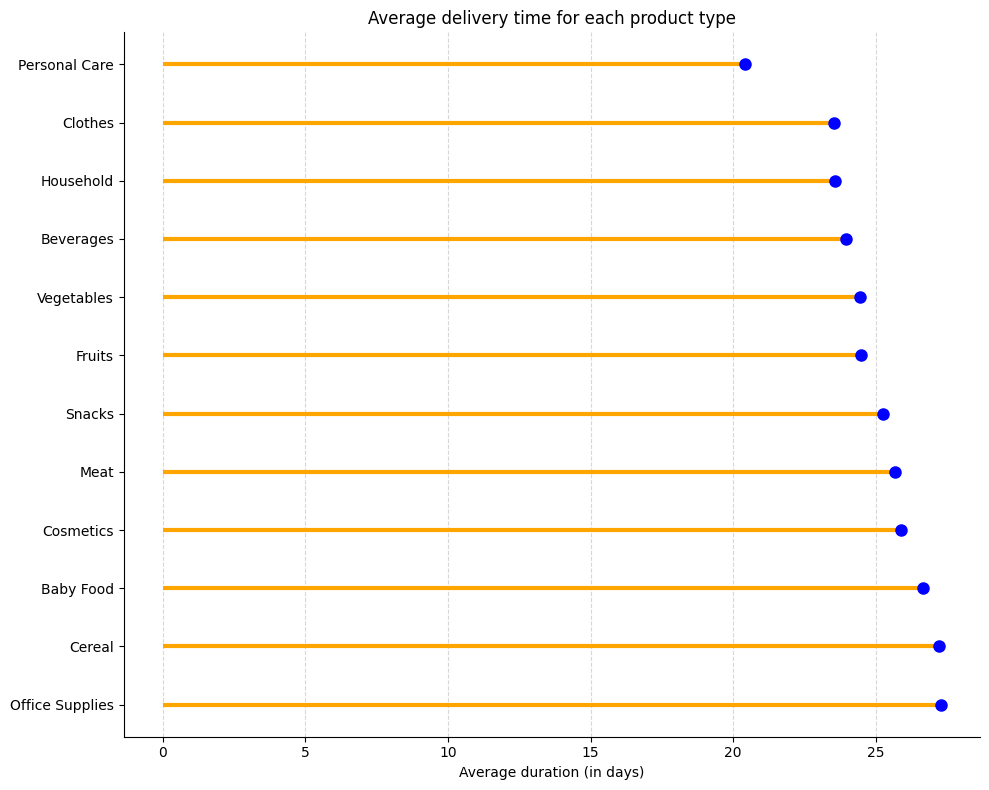

In [35]:

ship_items = store.groupby("item_type")["ship_time"].mean().sort_values() # calculate the average time from order to delivery

plt.figure(figsize=(10, 8))
plt.hlines(y=ship_items.index[::-1], xmin=0, xmax=ship_items.values[::-1], color='orange', linewidth=3)
plt.plot(ship_items.values[::-1], ship_items.index[::-1], "o", color='blue', markersize=8)

plt.xlabel('Average duration (in days)')
plt.title('Average delivery time for each product type')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_897/152811672.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=store, x='order_priority', y='ship_time',


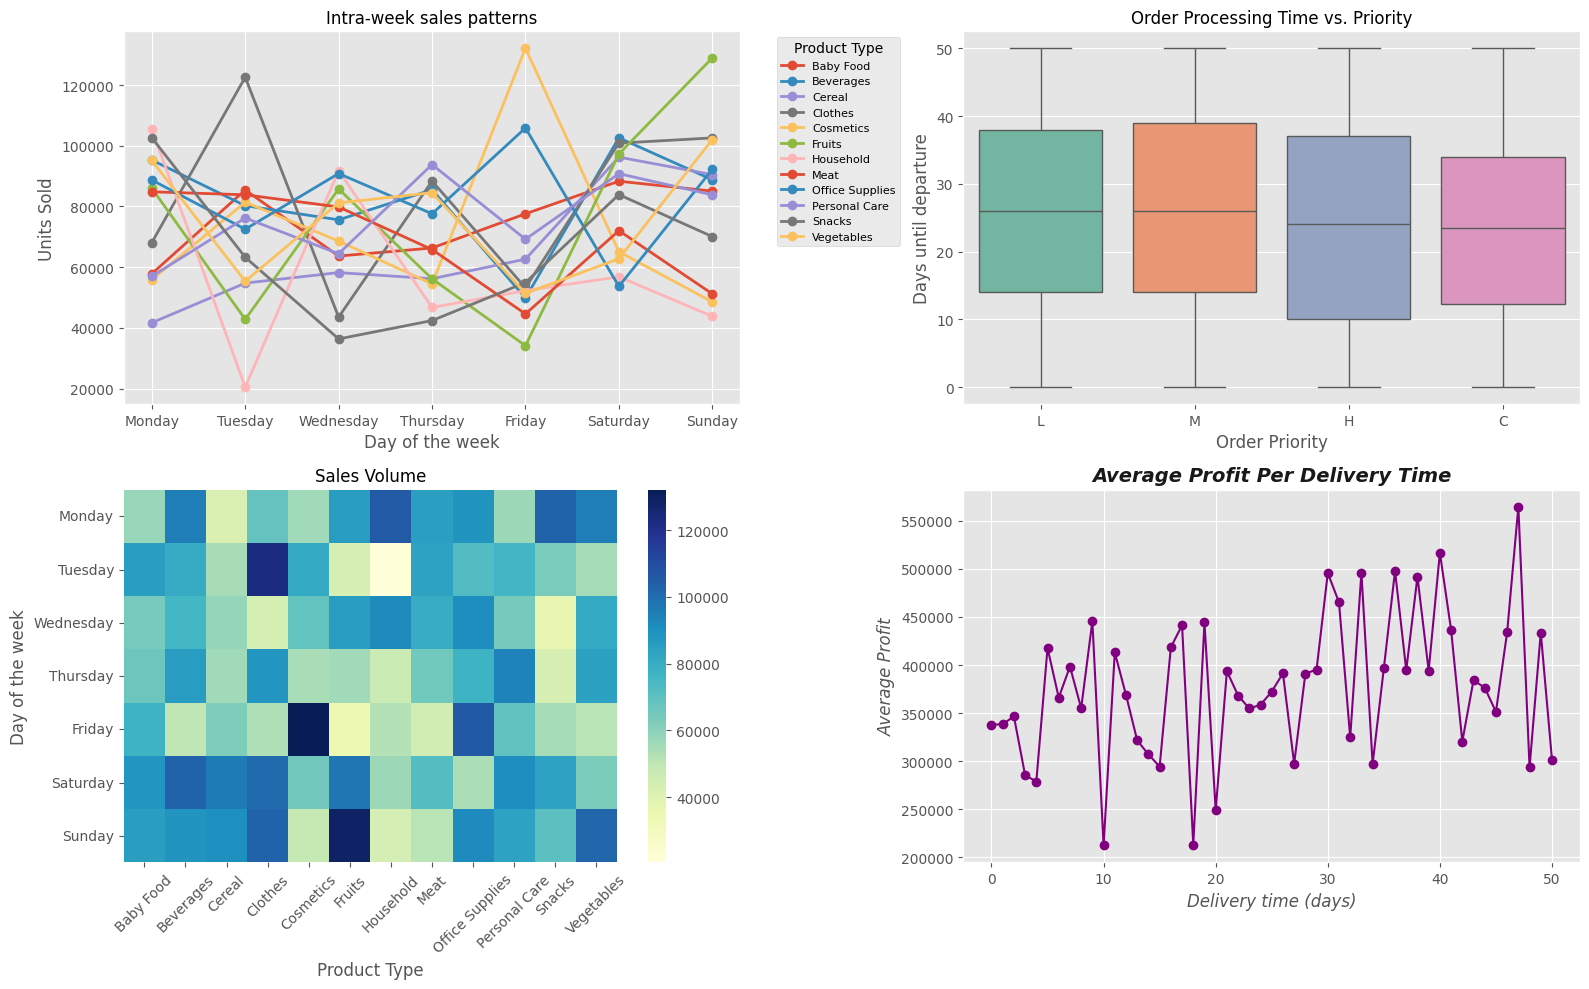

In [37]:

plt.style.use("ggplot")


fig, ax = plt.subplots(2, 2, figsize=(16, 10))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# We group the total number of items sold by day of the week and product type
weekly_trends = store.groupby(['days', 'item_type'])['units_sold'].sum().unstack()
weekly_trends = weekly_trends.reindex(days_order)

weekly_trends.plot(kind='line', marker='o', linewidth=2, ax=ax[0, 0])
ax[0, 0].set_title("Intra-week sales patterns", fontsize=12)
ax[0, 0].set_xlabel("Day of the week")
ax[0, 0].set_ylabel("Units Sold")

ax[0, 0].legend(title="Product Type", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

#Order processing time depending on priority
sns.boxplot(data=store, x='order_priority', y='ship_time',
            order=['L', 'M', 'H', 'C'], palette="Set2", ax=ax[0, 1])
ax[0, 1].set_title("Order Processing Time vs. Priority", fontsize=12)
ax[0, 1].set_xlabel("Order Priority")
ax[0, 1].set_ylabel("Days until departure")


pivot_days = store.pivot_table(index='days', columns='item_type', values='units_sold', aggfunc='sum')
pivot_days = pivot_days.reindex(days_order)


#Інтенсивність продажу товарів по днях тижня
sns.heatmap(pivot_days, cmap="YlGnBu", annot=False, ax=ax[1, 0])
ax[1, 0].set_title("Sales Volume", fontsize=12)
ax[1, 0].set_ylabel("Day of the week")
ax[1, 0].set_xlabel("Product Type")
ax[1, 0].tick_params(axis='x', rotation=45)

#прибуток залежно від часу доставки
agg = store.groupby("ship_time")["profit"].mean()
agg.plot(kind="line", marker="o", color="purple", ax=ax[1, 1])
ax[1, 1].set_title(
    "Average Profit Per Delivery Time",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
    color="black",
    alpha=0.9
)
ax[1, 1].set_xlabel("Delivery time (days)", fontsize=12, fontstyle="italic")
ax[1, 1].set_ylabel("Average Profit", fontsize=12, fontstyle="italic")

plt.tight_layout()
plt.show()

## Business Conclusions

Based on the data analysis, the following conclusions can be drawn:

1.  **Overall Profitability:** The company has a significant total profit of approximately **$474.18 million**.

2.  **Top Product Categories by Profit:**
    *   **Cosmetics** is the most profitable category.
    *   **Office Supplies** and **Household** are also among the top three.
    *   **Beverages** and **Fruits** are the least profitable categories and may require a review of pricing or marketing strategies.

3.  **Sales Channel Performance:**
    *   **Offline sales** generate slightly higher profits (approximately 238.92 million) compared to **online sales** (approximately 235.20 million). This highlights the importance of both channels and suggests that the online channel could be improved.

4.  **Processing and Delivery Times:**
    *   **Personal Care** and **Clothes** have the fastest average delivery times.
    *   **Office Supplies** and **Cereal** have the longest average delivery times. It might be worth investigating the logistics processes for these categories.
    *   **Order priority** has a clear impact on delivery time: high-priority orders (H – High, C – Critical) are processed faster.
    *   The relationship between average profit and delivery time is not linear. There are peak profit values at certain delivery times, which may indicate the optimal delivery times for maximizing profit.

6.  **Geographic Reach:** The company operates in 45 countries, with **Andorra, Ukraine, and Malta** leading in terms of profit.

## Business Recommendations
  *
    *   **Focus on high-margin categories:** Continue to actively develop and promote **Cosmetics, Office Supplies**, and **Household**, as these are the most profitable products across all categories.
    *   **Adopt a different strategy for low-margin products:** For **Beverages** and **Fruits**, analyze the possibility of raising prices, reducing costs, and conducting marketing campaigns

    *   **Examine and improve delivery processes for ‘Office Supplies’ and ‘Cereal’:** Since these categories have the longest average delivery times, it is necessary to identify weaknesses in logistics